Fraudes detectados: 8


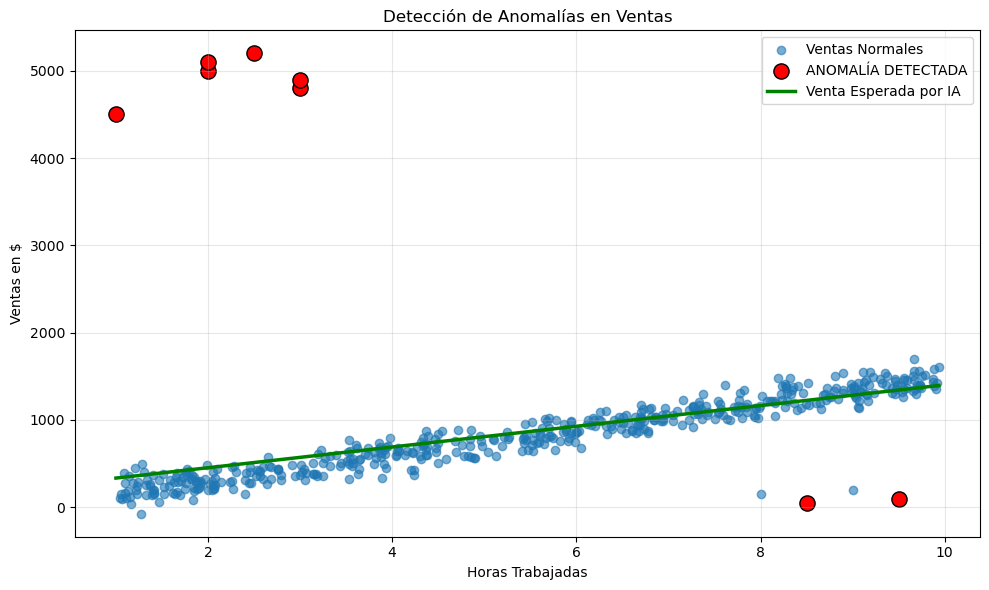

¡Guardado!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LinearRegression

np.random.seed(42)

# 1. DATOS
horas_trabajadas = np.random.uniform(1, 10, 490)
ventas = horas_trabajadas * 150 + np.random.normal(0, 100, 490)

horas_anomalas = np.array([2, 3, 2.5, 9, 8, 1, 9.5, 3, 8.5, 2])
ventas_anomalas = np.array([5000, 4800, 5200, 200, 150, 4500, 100, 4900, 50, 5100])

horas = np.concatenate([horas_trabajadas, horas_anomalas])
ventas_totales = np.concatenate([ventas, ventas_anomalas])

df = pd.DataFrame({'Horas_Trabajadas': horas, 'Ventas_$': ventas_totales})

# 2. MODELO
X = df[['Horas_Trabajadas']]
y = df['Ventas_$']

modelo = LinearRegression()
modelo.fit(X, y)

df['Venta_Esperada'] = modelo.predict(X)
df['Error'] = abs(df['Ventas_$'] - df['Venta_Esperada'])
limite_fraude = df['Error'].mean() + 2 * df['Error'].std()
df['Es_Anomalia'] = df['Error'] > limite_fraude

print(f"Fraudes detectados: {df['Es_Anomalia'].sum()}")

# 3. GRÁFICA ELEGANTE - Anti-bloqueo
plt.close('all')
fig = plt.figure(figsize=(10, 6))

normales = df[df['Es_Anomalia'] == False]
anomalias = df[df['Es_Anomalia'] == True]

plt.scatter(normales['Horas_Trabajadas'], normales['Ventas_$'], label='Ventas Normales', alpha=0.6)
plt.scatter(anomalias['Horas_Trabajadas'], anomalias['Ventas_$'], color='red', s=120, label='ANOMALÍA DETECTADA', edgecolors='black')

horas_ordenadas = df['Horas_Trabajadas'].sort_values()
plt.plot(horas_ordenadas, modelo.predict(horas_ordenadas.to_frame()), color='green', linewidth=2.5, label='Venta Esperada por IA')

plt.title('Detección de Anomalías en Ventas')
plt.xlabel('Horas Trabajadas')
plt.ylabel('Ventas en $')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig.savefig("deteccion_anomalias.png", dpi=150)
df.to_csv("ventas_con_anomalias.csv", index=False)

plt.show()
plt.close(fig) # Libera el archivo para que lo puedas borrar/mover
print("¡Guardado!")